# Analysis of NTK Eigenvalue and Eigenvector Distributions

We analyze the distributions of eigenvalues and eigenvectors of the NTK matrix.

In [15]:
import os
import numpy as np
import jax.numpy as jnp

import matplotlib.pyplot as plt
from tqdm import tqdm
import csv  # we use csv instead of pandas
from collections import defaultdict  # we use defaultdict for grouping
import json  # we add json for storing test results

In [16]:
import dotenv
dotenv.load_dotenv()
PROJECT_ROOT = os.getenv("PROJECT_ROOT")
PATH_TO_DATA = os.path.join(PROJECT_ROOT, "experiments", "data", "eigen")
PATH_TO_PLOTS = os.path.join(PROJECT_ROOT, "experiments", "plots", "eigen", "largest")
# we create necessary directories
os.makedirs(PATH_TO_PLOTS, exist_ok=True)

In [17]:
def get_config_from_filename(filename):
    """we extract configuration parameters from filename"""
    parts = filename.replace(".npy", "").split("_")
    N = int(parts[-4][1:])
    D = int(parts[-3][1:])
    M = int(parts[-2][1:])
    L = int(parts[-1][1:])
    return N, D, M, L

def load_experiment_data(N, D_IN, M, L):
    """we load eigenvalues and eigenvectors data for a specific configuration"""
    filename_eigenvalues = f"values/ntk_eigenvalues_N{N}_D{D_IN}_M{M}_L{L}.npy"
    filename_eigenvectors = f"vectors/ntk_eigenvectors_N{N}_D{D_IN}_M{M}_L{L}.npy"
    
    eigenvalues_data = np.load(os.path.join(PATH_TO_DATA, filename_eigenvalues), allow_pickle=True).item()
    eigenvectors_data = np.load(os.path.join(PATH_TO_DATA, filename_eigenvectors), allow_pickle=True).item()
    
    return eigenvalues_data, eigenvectors_data

In [21]:

def plot_largest_eigenvector_scalar_product_distribution(eigenvectors, N, D_IN, M, L, output_dir):
    """
    we analyze the distribution of the largest eigenvectors.
    for each configuration, we compute the mean of the largest eigenvectors (barycenter)
    and then plot the distribution of the scalar products of each largest eigenvector
    with this barycenter.
    """
    # we assume the largest eigenvector is at index 0
    # eigenvectors shape: (n_experiments, n_vectors, dimension)
    try:
        largest_eigenvectors = eigenvectors[:, -1, :] # shape (n_experiments, dimension)
        print(largest_eigenvectors)
    except IndexError:
        print(f"Warning: Could not extract largest eigenvector for config N{N}_D{D_IN}_M{M}_L{L}. Eigenvector array might be empty or have wrong dimensions.")
        return

    # we compute the barycenter (mean eigenvector)
    barycenter = np.mean(largest_eigenvectors, axis=0)

    # we normalize the barycenter to have unit norm for consistent scalar products
    barycenter_norm = np.linalg.norm(barycenter)
    if barycenter_norm < 1e-10:
        print(f"Warning: Barycenter norm is close to zero for config N{N}_D{D_IN}_M{M}_L{L}. Skipping plot.")
        return
    
    normalized_barycenter = barycenter / barycenter_norm

    # we compute the scalar product of each largest eigenvector with the normalized barycenter
    # eigenvectors are assumed to be unit vectors. The scalar product is the cosine similarity.
    scalar_products = np.dot(largest_eigenvectors, normalized_barycenter)

    # we plot the distribution of these scalar products
    plt.figure(figsize=(10, 6))
    plt.hist(scalar_products, bins='auto', density=True, alpha=0.7, label='Scalar Product Distribution')

    # we add mean and std dev to the plot
    mean_sp = np.mean(scalar_products)
    std_sp = np.std(scalar_products)
    plt.axvline(mean_sp, color='r', linestyle='--', linewidth=2, label=f'Mean: {mean_sp:.4f}')
    
    plt.title(f'Distribution of Largest Eigenvector Scalar Products with Barycenter\nConfig N{N}_D{D_IN}_M{M}_L{L}')
    plt.xlabel('Scalar Product (Cosine Similarity)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    
    # we add text box with statistics
    stats_text = f'Std Dev: {std_sp:.4f}\nMin: {np.min(scalar_products):.4f}\nMax: {np.max(scalar_products):.4f}'
    plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # we save the plot
    plot_filename = os.path.join(output_dir, f'largest_eigenvector_scalar_prod_dist_N{N}_D{D_IN}_M{M}_L{L}.png')
    plt.savefig(plot_filename, dpi=120)
    plt.show()
    plt.close()

Processing all experiment files for largest eigenvector analysis...


Processing experiment files:   0%|          | 0/1 [00:00<?, ?it/s]

[[-2.17827633e-01  3.59703928e-01  6.40723944e-01  2.86433190e-01
   1.93437617e-02 -3.93695801e-01  2.15509191e-01  3.58857512e-01]
 [-2.68409550e-02 -6.44782424e-01  2.44652778e-01  1.94512337e-01
   3.51293348e-02 -5.34988642e-01  2.73942351e-01  3.51217836e-01]
 [-5.67403257e-01  2.94218093e-01  7.88669065e-02 -2.76796132e-01
  -4.88472819e-01 -4.27095870e-07 -3.76486987e-01  3.58197391e-01]
 [-1.92647967e-02 -7.46341527e-01 -2.07855135e-01 -1.39331266e-01
  -1.22915752e-01 -4.63791788e-01  1.37135565e-01  3.61896694e-01]
 [-6.82807088e-01 -1.59327731e-01 -4.87948954e-01 -2.63124406e-01
   4.15031910e-02 -6.01451509e-02 -2.41796955e-01  3.70479256e-01]
 [-6.11346126e-01  5.37764616e-02 -5.89137450e-02  2.73047984e-01
  -3.01655173e-01  4.79466543e-02 -5.70266187e-01  3.56145859e-01]
 [ 4.02228236e-01  5.74257016e-01  8.10824931e-02 -4.87900138e-01
   1.74837887e-01 -3.05699427e-02  3.16293210e-01  3.63699138e-01]
 [ 5.94063640e-01 -8.07416742e-04  2.82309890e-01 -2.05254838e-01
  -

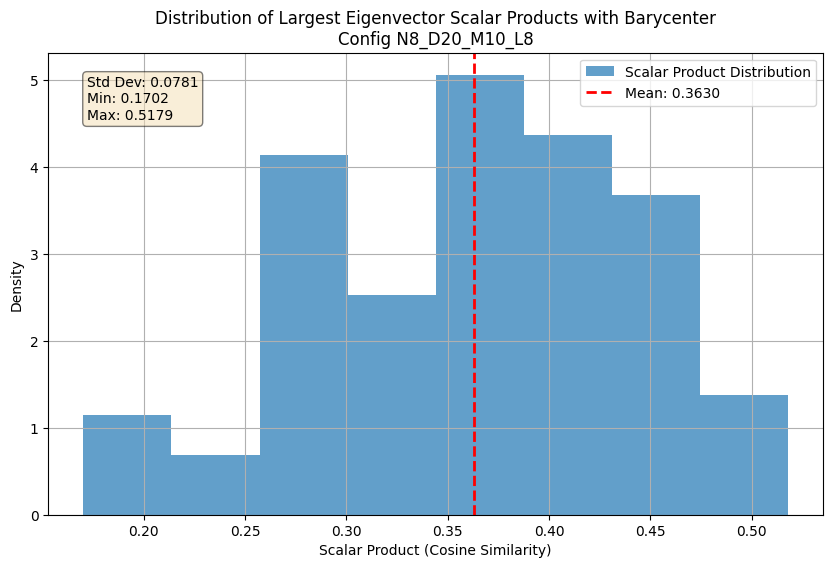

Processing experiment files: 100%|██████████| 1/1 [00:00<00:00,  6.29it/s]

Largest eigenvector analysis complete!


In [22]:
if __name__ == "__main__":
    # we process all files in the vectors directory
    files = [f for f in os.listdir(os.path.join(PATH_TO_DATA, "vectors")) if f.startswith('ntk_eigenvectors_')]
    
    # we sort files by N
    files = sorted(files, key=lambda x: get_config_from_filename(x)[0])
    
    files = files[:1]
    print("Processing all experiment files for largest eigenvector analysis...")
    print("=" * 60)
    
    for file in tqdm(files, desc="Processing experiment files"):
        try:
            # we extract configuration from filename
            N, D_IN, M, L = get_config_from_filename(file)
            
            # we load eigenvectors data
            _, eigenvectors_data = load_experiment_data(N, D_IN, M, L)
            
            # we plot the largest eigenvector scalar product distribution
            plot_largest_eigenvector_scalar_product_distribution(
                eigenvectors_data['eigenvectors'], N, D_IN, M, L, PATH_TO_PLOTS
            )
            
        except Exception as e:
            print(f"Error processing {file}: {e}")
    
    print("Largest eigenvector analysis complete!")